<h1 style='text-align: center'>The Quest for a Treasure</h1>
<h2 style='text-align: center'> A comparitive analysis of Informed and Uninformed Searches</h2>

### Background Story
In a magical forest, a brave explorer named Arin sets out on an exciting adventure to find a treasure, hidden inside an ancient temple. The forest is like a giant maze, full of secret paths, magical barriers, and tricky traps.

Arin begins the journey at Campfire Point (S) and must find a way through the maze to reach the Temple (G), facing many challenges along the way.


### Graph Representation of the Forest
The enchanted forest is represented as a graph, where:

<ul>
        <li>Each node represents a location in the forest.</li>
        <li>Each edge represents a valid path.</li>
        <li>Some edges have higher costs due to difficult terrain.</li>
        <li>Portals act as direct jumps between distant nodes, bypassing obstacles.</li>
    </ul>
    
    

  
    
 <h2>Terrain Information</h2>
<p>Each terrain type in the forest has an associated movement cost as follows:</p>

<table border="1">
    <tr>
        <th>Terrain Type</th>
        <th>Marker</th>
        <th>Description</th>
        <th>Cost</th>
        <th>Color</th>
    </tr>
    <tr>
        <td>Normal Path</td>
        <td>0</td>
        <td>Walkable terrain</td>
        <td>1</td>
        <td>Light Gray</td>
    </tr>
    <tr>
        <td>Wall (❌)</td>
        <td>-1</td>
        <td>Impassable obstacle</td>
        <td>∞ (Not allowed)</td>
        <td>White</td>
    </tr>
    <tr>
        <td>Quicksand (⏳)</td>
        <td>2</td>
        <td>Slows movement</td>
        <td>3</td>
        <td>Yellow</td>
    </tr>
    <tr>
        <td>Portal (🔄)</td>
        <td>3</td>
        <td>Instantly moves to exit</td>
        <td>0 (Teleportation)</td>
        <td>Purple</td>
    </tr>
    <tr>
        <td>Wild Beasts (⚠️)</td>
        <td>4</td>
        <td>Dangerous area</td>
        <td>5</td>
        <td>Red</td>
    </tr>
    <tr>
        <td>Start (S)</td>
        <td>5</td>
        <td>Starting position</td>
        <td>0</td>
        <td>Green</td>
    </tr>
    <tr>
        <td>Goal (G)</td>
        <td>6</td>
        <td>Target location</td>
        <td>0</td>
        <td>Blue</td>
    </tr>
</table>


<h2>Task: Finding the Optimal Path</h2>
<p>Your goal is to find the optimal path from S (Campfire Point) to G (Temple of Lumora) using four search strategies.</p>

<h3>Search Strategies to Implement</h3>

You have to implement the following search strategies:
<ul>
    <li>Breadth-First Search (BFS)</li>
    <li>Depth-First Search (DFS)</li>
    <li>Uniform-Cost Search (UCS)</li>
    <li>Greedy Best-First Search (GBFS) (using the most appropriate heuristic)</li>
    <li>A* Search (using the most appropriate heuristic)</li>
</ul>


<h3>Performance Evaluation</h3>
<p>For each search algorithm, track and compare its performance based on the following metrics:</p>
<ul>
    <li> Path found (if any) and its total cost.</li>
    <li> Number of nodes expanded.</li>
    <li> Execution time (using Python’s time module).</li>
    <li> Memory usage (using Python’s psutil or tracemalloc module).</li>
    <li> List of all obstacles faced during the search process.</li>
</ul>

<h3>Visualization Requirements</h3>
<p Generate visualizations to better understand the search performance:</p>
<ul>
    <li>Graph or heatmap of the search process.</li>
    <li>Comparative bar charts showing execution time and memory usage for each algorithm</li>
</ul>

<h3> Hints & Guidelines:</h3>
<ul>
    <li>Use Matplotlib to visualize the paths and performance comparisons.</li>
    <li>Experiment with different heuristics for A* and compare results.</li>
    <li>Use Python’s psutil or tracemalloc module for memory analysis of each algorithm. </li>
</ul>

### Importing Necessary Modules/Functions


In [4]:
# Random and numpy array imported
from random import randint
from numpy import array

<p style='color: red'>No Changes Should be Made to This Cell</p>

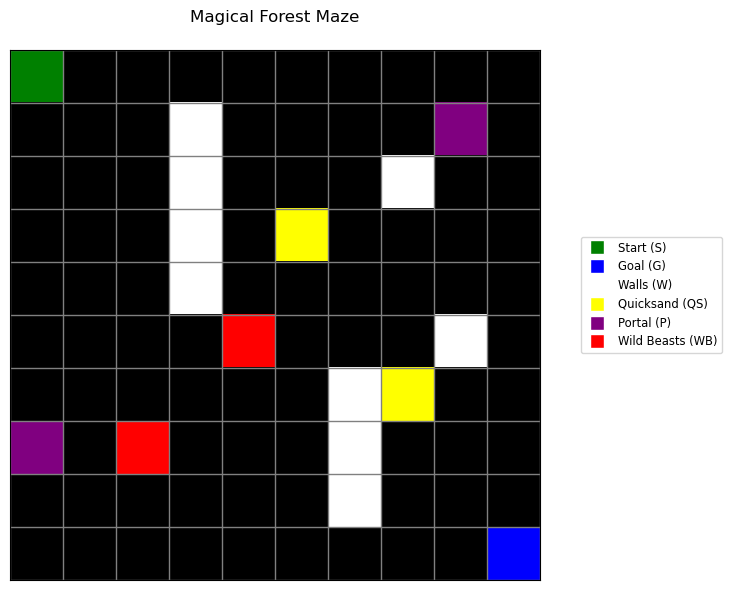

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define grid size
N, M = 10, 10  

# Define symbols
START, GOAL = (0, 0), (9, 9)
WALL, PATH, QUICKSAND, PORTAL, BEAST = -1, 0, 2, 3, 4

# Create an empty grid
grid = np.zeros((N, M))

# Add walls in a controlled manner
walls = [(1, 3), (2, 3), (3, 3), (4, 3), (6, 6), (7, 6), (8, 6), (5, 8), (2, 7)]
for w in walls:
    grid[w] = WALL

# Ensure a clear path by removing unnecessary blockages
clear_path = [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5)]
for p in clear_path:
    grid[p] = PATH

# Add special terrain strategically
grid[3, 5] = QUICKSAND  # Slower path
grid[6, 7] = QUICKSAND  # Another slow zone
grid[5, 4] = BEAST  # Dangerous zone
grid[7, 2] = BEAST  # Another dangerous area

# Place portals strategically
grid[1, 8] = PORTAL  # Portal entrance
grid[7, 0] = PORTAL  # Portal exit

# Mark start and goal
grid[START] = 5  # Start point
grid[GOAL] = 6  # Goal point

# Define colormap for visualization
cmap = mcolors.ListedColormap(["white", "black", "yellow", "purple", "red", "green", "blue"])
bounds = [-1.5, -0.5, 0.5, 2.5, 3.5, 4.5, 5.5, 6.5]  # Boundaries for colors
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot the grid with color representation
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(grid, cmap=cmap, norm=norm, interpolation="nearest")

# Add grid lines and labels
ax.set_xticks(np.arange(N + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(M + 1) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=1)
ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

# Add legend outside the plot
legend_patches = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="green", markersize=10, label="Start (S)"),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="blue", markersize=10, label="Goal (G)"),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="white", markersize=10, label="Walls (W)"),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="yellow", markersize=10, label="Quicksand (QS)"),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="purple", markersize=10, label="Portal (P)"),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="red", markersize=10, label="Wild Beasts (WB)")
]

fig.legend(handles=legend_patches, loc="center left", fontsize="small", bbox_to_anchor=(1, 0.5))

plt.title("Magical Forest Maze", pad=20)
plt.tight_layout()
plt.show()


## Start Your Work From Here!

<p style='color: green'>You Can Start Writing Code and Make Changes to It from Here and Onwards</p>

<hr style="height:1px;border:none;color:#333;background-color:#333;" />


==================== Running BFS ====================
Path found with cost: 14
Nodes expanded: 91
Time taken: 0.0011 seconds
Memory used: 0.01 MB

Obstacles encountered:
- Quicksand: 0
- Portals: 2
- Wild Beasts: 0


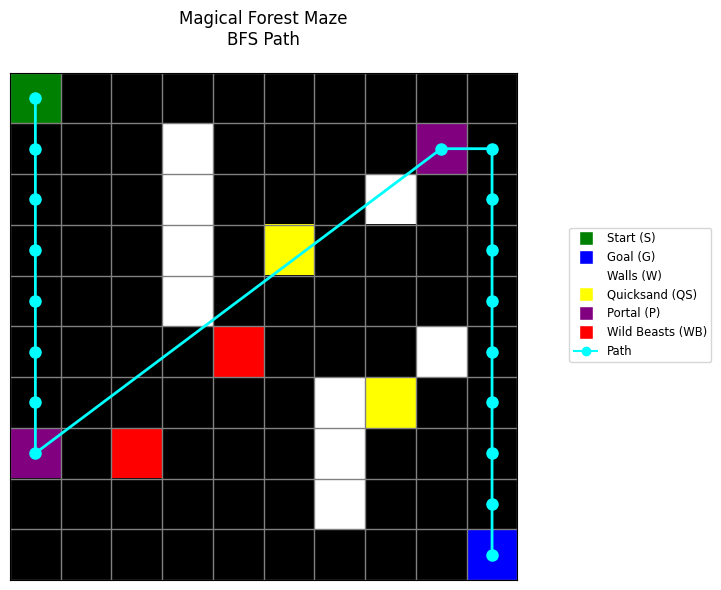


==================== Running DFS ====================
Path found with cost: 17
Nodes expanded: 19
Time taken: 0.0004 seconds
Memory used: 0.01 MB

Obstacles encountered:
- Quicksand: 0
- Portals: 0
- Wild Beasts: 0


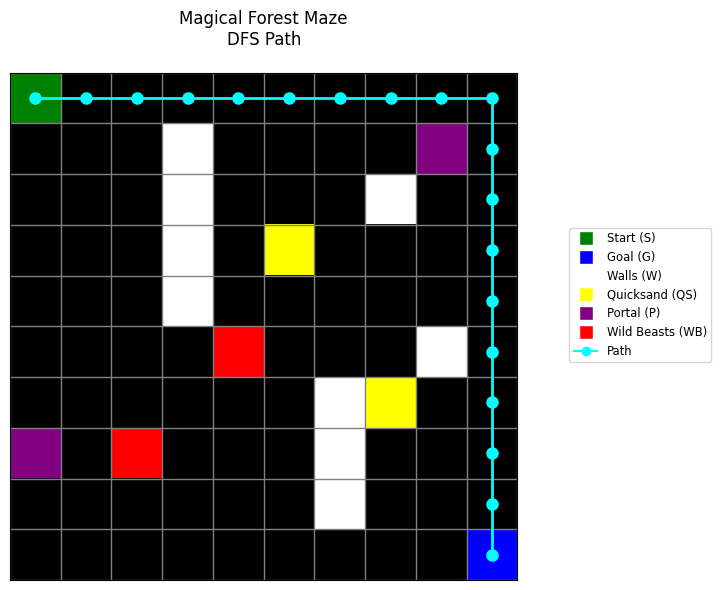


==================== Running UCS ====================
Path found with cost: 14
Nodes expanded: 86
Time taken: 0.0014 seconds
Memory used: 0.01 MB

Obstacles encountered:
- Quicksand: 0
- Portals: 2
- Wild Beasts: 0


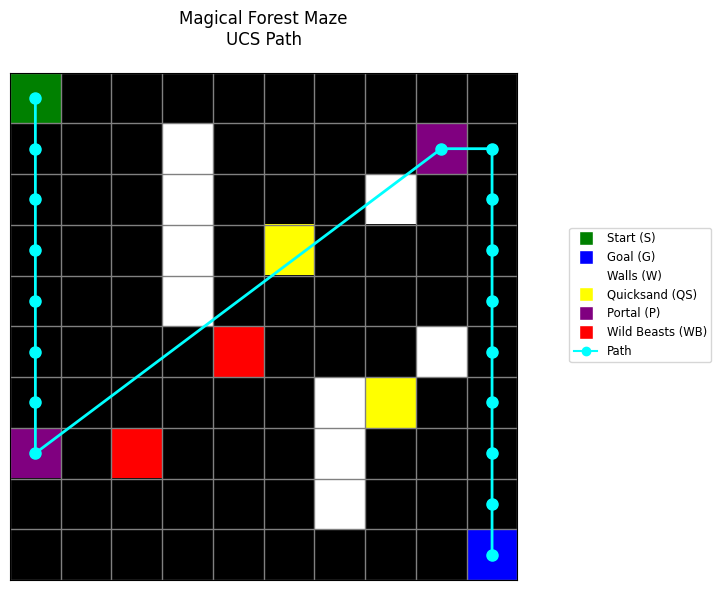


==================== Running GBFS ====================
Path found with cost: 17
Nodes expanded: 19
Time taken: 0.0003 seconds
Memory used: 0.01 MB

Obstacles encountered:
- Quicksand: 0
- Portals: 0
- Wild Beasts: 0


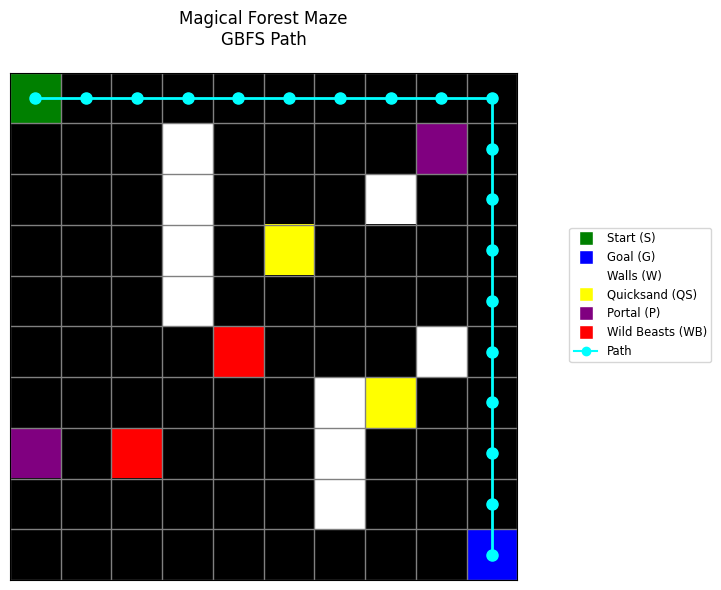


==================== Running A* ====================
Path found with cost: 14
Nodes expanded: 39
Time taken: 0.0007 seconds
Memory used: 0.00 MB

Obstacles encountered:
- Quicksand: 0
- Portals: 2
- Wild Beasts: 0


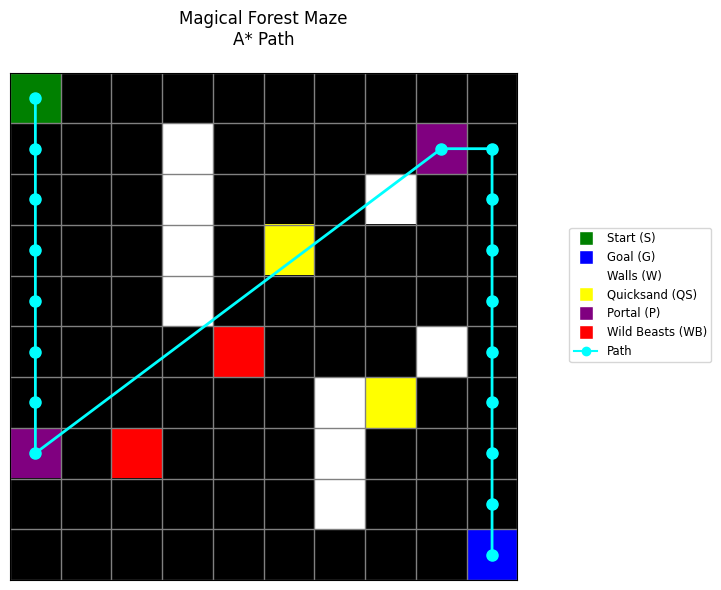

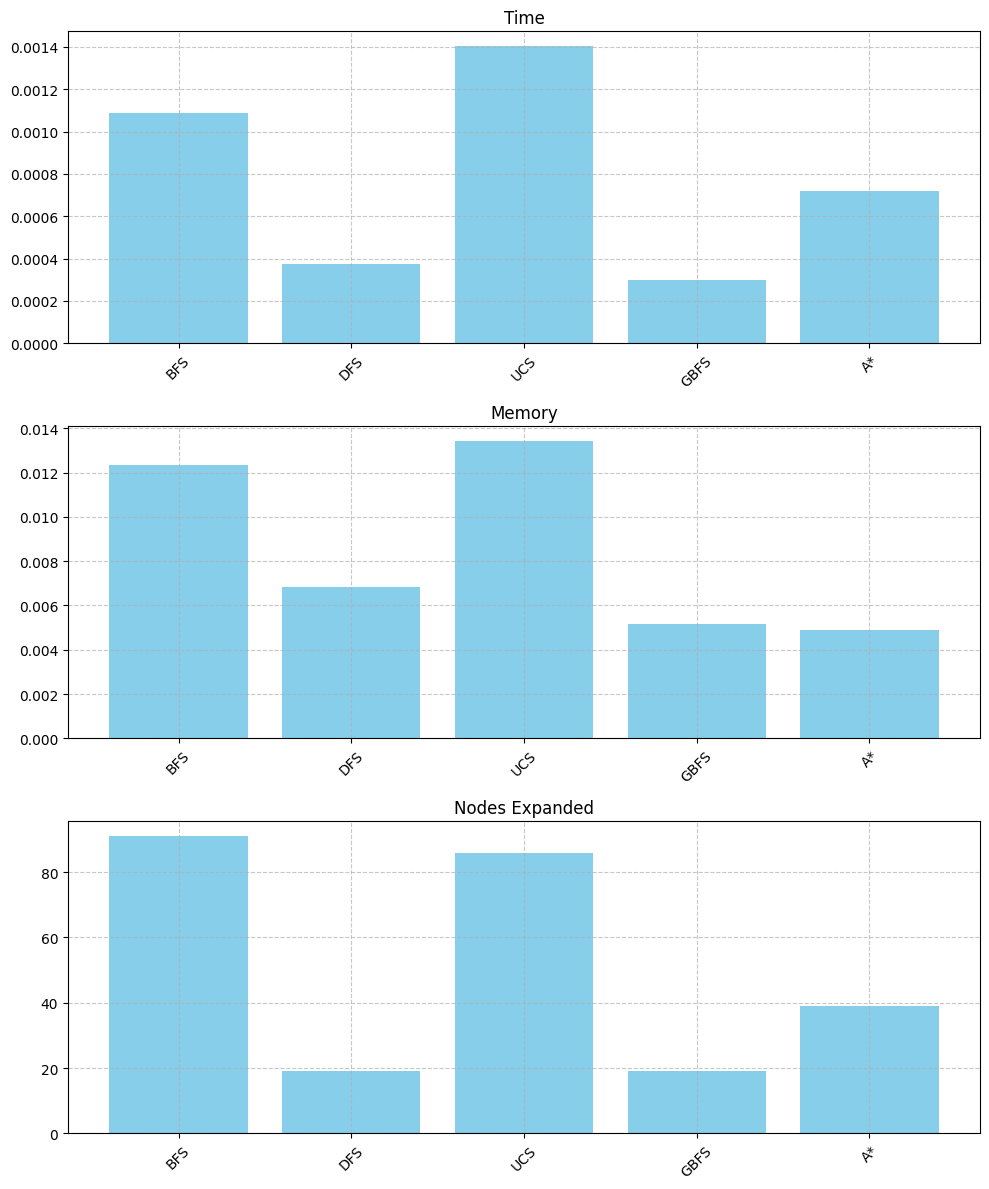

In [1]:
# Search Algorithms Code
from collections import deque
import heapq
import time
import tracemalloc
from typing import List, Tuple, Dict

class SearchAgent:
    def __init__(self, grid):
        self.grid = grid
        self.rows, self.cols = grid.shape
        self.start = (0, 0)
        self.goal = (9, 9)
        # Add portal pairs mapping
        self.portal_pairs = {(1, 8): (7, 0), (7, 0): (1, 8)}  # bidirectional portals

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        
        # First check if current position is a portal
        if self.grid[pos] == 3:  # Portal
            portal_dest = self.portal_pairs.get(pos)
            if portal_dest:
                neighbors.append(portal_dest)
                
        # Add regular adjacent neighbors
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:  # right, down, left, up
            new_x, new_y = x + dx, y + dy
            if (0 <= new_x < self.rows and 
                0 <= new_y < self.cols and 
                self.grid[new_x, new_y] != -1):  # not a wall
                neighbors.append((new_x, new_y))
                
        return neighbors
    
    def get_cost(self, pos: Tuple[int, int]) -> int:
        cell_type = self.grid[pos]
        # Terrain costs as per specification
        costs = {
            0: 1,    # Normal Path
            -1: float('inf'),  # Wall
            2: 3,    # Quicksand
            3: 0,    # Portal
            4: 5,    # Wild Beasts
            5: 0,    # Start
            6: 0     # Goal
        }
        return costs.get(cell_type, float('inf'))
        
    def manhattan_distance(self, pos: Tuple[int, int]) -> int:
        return abs(pos[0] - self.goal[0]) + abs(pos[1] - self.goal[1])

    def bfs(self):
        tracemalloc.start()
        start_time = time.time()
        
        queue = deque([(self.start, [self.start])])  # Removed cost
        visited = {self.start}
        nodes_expanded = 0
        
        while queue:
            current, path = queue.popleft()  # Removed cost unpacking
            nodes_expanded += 1
            
            if current == self.goal:
                # Calculate cost only after finding path
                path_cost = sum(self.get_cost(pos) for pos in path[1:])  # Skip start position
                end_time = time.time()
                memory_current, memory_peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                return {
                    'path': path,
                    'cost': path_cost,
                    'nodes_expanded': nodes_expanded,
                    'time': end_time - start_time,
                    'memory': memory_peak / 10**6  # Convert to MB
                }
            
            for next_pos in self.get_neighbors(current):
                if next_pos not in visited:
                    visited.add(next_pos)
                    queue.append((next_pos, path + [next_pos]))  # Removed cost tracking

    def dfs(self):
        tracemalloc.start()
        start_time = time.time()
        
        stack = [(self.start, [self.start])]  # Removed cost
        visited = {self.start}
        nodes_expanded = 0
        
        while stack:
            current, path = stack.pop()  # Removed cost unpacking
            nodes_expanded += 1
            
            if current == self.goal:
                # Calculate cost only after finding path
                path_cost = sum(self.get_cost(pos) for pos in path[1:])  # Skip start position
                end_time = time.time()
                memory_current, memory_peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                return {
                    'path': path,
                    'cost': path_cost,
                    'nodes_expanded': nodes_expanded,
                    'time': end_time - start_time,
                    'memory': memory_peak / 10**6
                }
            
            for next_pos in reversed(self.get_neighbors(current)):
                if next_pos not in visited:
                    visited.add(next_pos)
                    stack.append((next_pos, path + [next_pos]))  # Removed cost tracking

    def ucs(self):
        tracemalloc.start()
        start_time = time.time()
        
        pq = [(0, self.start, [self.start])]
        visited = set()
        nodes_expanded = 0
        
        while pq:
            cost, current, path = heapq.heappop(pq)
            
            if current in visited:
                continue
                
            visited.add(current)
            nodes_expanded += 1
            
            if current == self.goal:
                end_time = time.time()
                memory_current, memory_peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                return {
                    'path': path,
                    'cost': cost,
                    'nodes_expanded': nodes_expanded,
                    'time': end_time - start_time,
                    'memory': memory_peak / 10**6
                }
            
            for next_pos in self.get_neighbors(current):
                if next_pos not in visited:
                    new_cost = cost + self.get_cost(next_pos)
                    heapq.heappush(pq, (new_cost, next_pos, path + [next_pos]))
        
        tracemalloc.stop()
        return None

    def gbfs(self):
        tracemalloc.start()
        start_time = time.time()
        
        pq = [(self.manhattan_distance(self.start), self.start, [self.start], 0)]
        visited = set()
        nodes_expanded = 0
        
        while pq:
            _, current, path, cost = heapq.heappop(pq)
            
            if current in visited:
                continue
                
            visited.add(current)
            nodes_expanded += 1
            
            if current == self.goal:
                end_time = time.time()
                memory_current, memory_peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                return {
                    'path': path,
                    'cost': cost,
                    'nodes_expanded': nodes_expanded,
                    'time': end_time - start_time,
                    'memory': memory_peak / 10**6
                }
            
            for next_pos in self.get_neighbors(current):
                if next_pos not in visited:
                    new_cost = cost + self.get_cost(next_pos)
                    heapq.heappush(pq, (
                        self.manhattan_distance(next_pos),
                        next_pos,
                        path + [next_pos],
                        new_cost
                    ))
        
        tracemalloc.stop()
        return None

    def astar(self):
        tracemalloc.start()
        start_time = time.time()
        
        pq = [(0 + self.manhattan_distance(self.start), 0, self.start, [self.start])]
        visited = set()
        nodes_expanded = 0
        
        while pq:
            _, cost, current, path = heapq.heappop(pq)
            
            if current in visited:
                continue
                
            visited.add(current)
            nodes_expanded += 1
            
            if current == self.goal:
                end_time = time.time()
                memory_current, memory_peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                return {
                    'path': path,
                    'cost': cost,
                    'nodes_expanded': nodes_expanded,
                    'time': end_time - start_time,
                    'memory': memory_peak / 10**6
                }
            
            for next_pos in self.get_neighbors(current):
                if next_pos not in visited:
                    new_cost = cost + self.get_cost(next_pos)
                    f_cost = new_cost + self.manhattan_distance(next_pos)
                    heapq.heappush(pq, (f_cost, new_cost, next_pos, path + [next_pos]))
        
        tracemalloc.stop()
        return None


# Visualizer Code
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

class Visualizer:
    def __init__(self, grid):
        self.grid = grid
        self.rows, self.cols = grid.shape
        self.cmap = mcolors.ListedColormap(["white", "black", "yellow", "purple", "red", "green", "blue"])
        self.bounds = [-1.5, -0.5, 0.5, 2.5, 3.5, 4.5, 5.5, 6.5]
        self.norm = mcolors.BoundaryNorm(self.bounds, self.cmap.N)

    def plot_path(self, path, algorithm_name):
        if not path:
            print(f"No path found for {algorithm_name}")
            return

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(self.grid, cmap=self.cmap, norm=self.norm, interpolation="nearest")

        # Add grid lines and labels
        ax.set_xticks(np.arange(self.cols + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(self.rows + 1) - 0.5, minor=True)
        ax.grid(which="minor", color="gray", linestyle='-', linewidth=1)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

        # Plot the path
        if path:
            path_y, path_x = zip(*path)
            plt.plot(path_x, path_y, 'o-', color='cyan', linewidth=2, markersize=8)

        # Add legend
        legend_patches = [
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="green", markersize=10, label="Start (S)"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="blue", markersize=10, label="Goal (G)"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="white", markersize=10, label="Walls (W)"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="yellow", markersize=10, label="Quicksand (QS)"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="purple", markersize=10, label="Portal (P)"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor="red", markersize=10, label="Wild Beasts (WB)"),
            plt.Line2D([0], [0], marker='o', color='cyan', label="Path")
        ]

        fig.legend(handles=legend_patches, loc="center left", fontsize="small", bbox_to_anchor=(1, 0.5))
        plt.title(f"Magical Forest Maze\n{algorithm_name} Path", pad=20)
        plt.tight_layout()
        plt.show()

    def plot_performance_comparison(self, results):
        metrics = ['time', 'memory', 'nodes_expanded']
        algorithms = list(results.keys())
        
        fig, axes = plt.subplots(3, 1, figsize=(10, 12))
        
        for idx, metric in enumerate(metrics):
            values = [results[alg][metric] for alg in algorithms]
            axes[idx].bar(algorithms, values, color='skyblue')
            axes[idx].set_title(f'{metric.replace("_", " ").title()}')
            axes[idx].tick_params(axis='x', rotation=45)
            axes[idx].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()


# main
import numpy as np
from search_algorithms import SearchAgent
from visualizer import Visualizer

def main():
    # Initialize grid with normal paths
    N, M = 10, 10
    grid = np.zeros((N, M))
    
    # Define terrain features exactly as shown in the image
    walls = [(1, 3), (2, 3), (3, 3), (4, 3), (6, 6), (7, 6), (8, 6), (5, 8), (2, 7)]
    quicksand = [(3, 5), (6, 7)]
    portals = [(1, 8), (7, 0)]
    beasts = [(5, 4), (7, 2)]
    
    # Place terrain features on grid
    for w in walls:
        grid[w] = -1  # Walls (white)
    for qs in quicksand:
        grid[qs] = 2  # Quicksand (yellow)
    for p in portals:
        grid[p] = 3  # Portals (purple)
    for b in beasts:
        grid[b] = 4  # Wild Beasts (red)
    
    # Set start and goal
    grid[0, 0] = 5  # Start - green
    grid[9, 9] = 6  # Goal - blue
    
    # Initialize search agent and visualizer
    agent = SearchAgent(grid)
    viz = Visualizer(grid)
    
    # Track obstacles encountered for each algorithm
    def track_path_obstacles(path, grid):
        obstacles = {
            'Quicksand': 0,
            'Portals': 0,
            'Wild Beasts': 0
        }
        for x, y in path:
            cell = grid[x, y]
            if cell == 2:
                obstacles['Quicksand'] += 1
            elif cell == 3:
                obstacles['Portals'] += 1
            elif cell == 4:
                obstacles['Wild Beasts'] += 1
        return obstacles

    # Run all search algorithms
    algorithms = {
        'BFS': agent.bfs,
        'DFS': agent.dfs,
        'UCS': agent.ucs,
        'GBFS': agent.gbfs,
        'A*': agent.astar
    }
    
    results = {}
    
    for name, algorithm in algorithms.items():
        print(f"\n{'='*20} Running {name} {'='*20}")
        result = algorithm()
        if result:
            results[name] = result
            obstacles = track_path_obstacles(result['path'], grid)
            print(f"Path found with cost: {result['cost']}")
            print(f"Nodes expanded: {result['nodes_expanded']}")
            print(f"Time taken: {result['time']:.4f} seconds")
            print(f"Memory used: {result['memory']:.2f} MB")
            print("\nObstacles encountered:")
            for obstacle, count in obstacles.items():
                print(f"- {obstacle}: {count}")
            viz.plot_path(result['path'], name)
        else:
            print(f"No path found for {name}")
    
    # Plot performance comparison
    viz.plot_performance_comparison(results)

if __name__ == "__main__":
    main()


<hr style="height:1px;border:none;color:#333;background-color:#333;" />